In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

In [3]:
from scipy.stats import linregress

print("SciPy installed successfully ✅")

SciPy installed successfully ✅


In [4]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

In [5]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [6]:
nav_df = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [7]:
nav_df = nav_df.sort_values(
    ["scheme_name", "date"]
)

In [8]:
nav_df["daily_return"] = (
    nav_df
    .groupby("scheme_name")["nav"]
    .pct_change()
)

In [9]:
nav_df.head(10)

,amfi_code,date,nav,scheme_name,daily_return
32200,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
32201,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
32202,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
32203,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
32204,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314
32205,101206,2022-01-10,307.5591,ABSL Frontline Equity Fund - Regular - Growth,0.011548
32206,101206,2022-01-11,309.4372,ABSL Frontline Equity Fund - Regular - Growth,0.006106
32207,101206,2022-01-12,313.2022,ABSL Frontline Equity Fund - Regular - Growth,0.012167
32208,101206,2022-01-13,310.7396,ABSL Frontline Equity Fund - Regular - Growth,-0.007863
32209,101206,2022-01-14,308.9641,ABSL Frontline Equity Fund - Regular - Growth,-0.005714


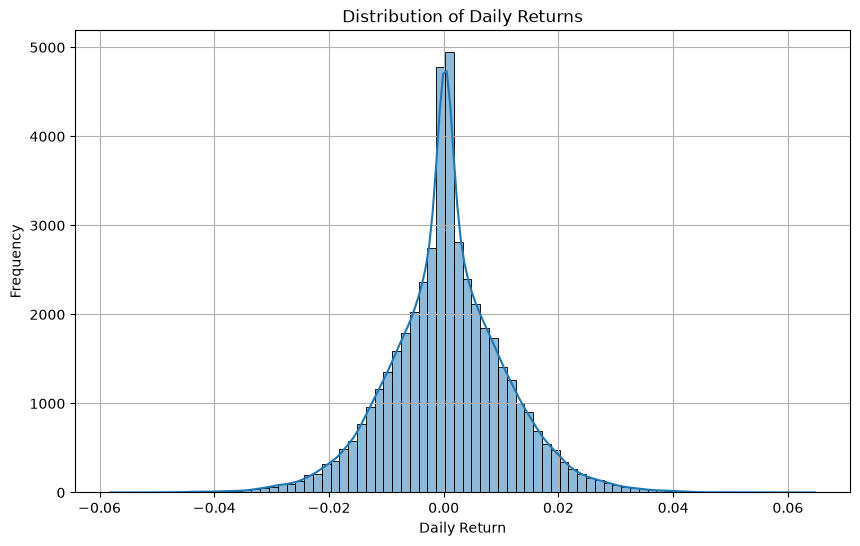

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=80,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# Daily Return Analysis

## Objective

Compute daily returns for all 40 mutual fund schemes.

## Formula

Daily Return = (Today's NAV / Previous Day's NAV) − 1

## Observation

The daily return distribution is centered close to zero with both positive and negative returns, which is expected for mutual fund NAV movements.

In [11]:
nav_df.groupby("scheme_name")["date"].agg(["min","max"]).head()

,min,max
scheme_name,,
ABSL Frontline Equity Fund - Regular - Growth,2022-01-03,2026-05-29
ABSL Liquid Fund - Regular - Growth,2022-01-03,2026-05-29
ABSL Small Cap Fund - Regular - Growth,2022-01-03,2026-05-29
Axis Bluechip Fund - Direct - Growth,2022-01-03,2026-05-29
Axis Bluechip Fund - Regular - Growth,2022-01-03,2026-05-29


In [12]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [13]:
cagr_results = []

In [29]:
for scheme in nav_df["scheme_name"].unique():

    scheme_df = (
        nav_df[nav_df["scheme_name"] == scheme]
        .sort_values("date")
        .reset_index(drop=True)
    )

    latest_date = scheme_df["date"].max()
    latest_nav = scheme_df.iloc[-1]["nav"]

    result = {
        "scheme_name": scheme
    }

    # ---------- 1 Year CAGR ----------
    start_date = latest_date - pd.DateOffset(years=1)

    df = scheme_df[scheme_df["date"] >= start_date]

    if len(df) > 0:
        start_nav = df.iloc[0]["nav"]
        result["CAGR_1Y (%)"] = calculate_cagr(start_nav, latest_nav, 1) * 100
    else:
        result["CAGR_1Y (%)"] = np.nan

    # ---------- 3 Year CAGR ----------
    start_date = latest_date - pd.DateOffset(years=3)

    df = scheme_df[scheme_df["date"] >= start_date]

    if len(df) > 0:
        start_nav = df.iloc[0]["nav"]
        result["CAGR_3Y (%)"] = calculate_cagr(start_nav, latest_nav, 3) * 100
    else:
        result["CAGR_3Y (%)"] = np.nan

    # ---------- 5 Year CAGR ----------
    start_date = latest_date - pd.DateOffset(years=5)

    if scheme_df["date"].min() <= start_date:

        df = scheme_df[scheme_df["date"] >= start_date]

        start_nav = df.iloc[0]["nav"]

        result["CAGR_5Y (%)"] = calculate_cagr(start_nav, latest_nav, 5) * 100

    else:

        result["CAGR_5Y (%)"] = np.nan

    cagr_results.append(result)

In [30]:
cagr_df = pd.DataFrame(cagr_results)

In [31]:
cagr_df = cagr_df.round(2)

In [32]:
cagr_df = cagr_df.sort_values(
    "CAGR_3Y (%)",
    ascending=False
)

In [33]:
print(cagr_df.shape)
cagr_df.head()

(40, 4)


,scheme_name,CAGR_1Y (%),CAGR_3Y (%),CAGR_5Y (%)
5,Axis Midcap Fund - Regular - Growth,22.26,35.11,NaN
25,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,NaN
15,ICICI Pru Bluechip Fund - Direct - Growth,13.06,32.49,NaN
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,NaN
18,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,NaN


In [28]:
cagr_results = []

In [34]:
cagr_df.columns

Index(['scheme_name', 'CAGR_1Y (%)', 'CAGR_3Y (%)', 'CAGR_5Y (%)'], dtype='str')

In [35]:
cagr_df.to_csv("../reports/cagr_comparison.csv", index=False)

print("✅ CAGR comparison file saved successfully.")

✅ CAGR comparison file saved successfully.


In [36]:
risk_free_rate = 0.065

In [37]:
sharpe_results = []

In [38]:
for scheme in nav_df["scheme_name"].unique():

    df = nav_df[nav_df["scheme_name"] == scheme]

    returns = df["daily_return"].dropna()

    annual_return = returns.mean() * 252

    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (annual_return - risk_free_rate) / annual_volatility

    sharpe_results.append({
        "scheme_name": scheme,
        "Annual Return (%)": annual_return * 100,
        "Annual Volatility (%)": annual_volatility * 100,
        "Sharpe Ratio": sharpe
    })

In [39]:
sharpe_df = pd.DataFrame(sharpe_results)

In [40]:
sharpe_df = sharpe_df.round(2)

In [41]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe Ratio",
    ascending=False
)

In [42]:
print(sharpe_df.shape)

sharpe_df.head(10)

(40, 4)


,scheme_name,Annual Return (%),Annual Volatility (%),Sharpe Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,27.06,14.19,1.45
22,Kotak Flexicap Fund - Regular - Growth,27.26,15.89,1.31
26,Mirae Asset Tax Saver Fund - Regular - Growth,28.33,17.67,1.23
33,SBI Bluechip Fund - Regular Plan - Growth,23.10,13.74,1.21
18,ICICI Pru Midcap Fund - Regular - Growth,29.27,19.29,1.18
7,DSP Midcap Fund - Regular - Growth,26.59,17.75,1.13
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.21,18.94,1.09
30,Nippon India Large Cap Fund - Regular - Growth,21.80,14.15,1.08
0,ABSL Frontline Equity Fund - Regular - Growth,21.46,14.57,1.03
15,ICICI Pru Bluechip Fund - Direct - Growth,21.24,14.36,1.03


In [43]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("✅ Sharpe Ratio file saved successfully.")

✅ Sharpe Ratio file saved successfully.


# Sharpe Ratio Analysis

## Objective

Evaluate the risk-adjusted performance of all mutual fund schemes.

## Formula

Sharpe Ratio = (Annual Return − Risk-Free Rate) / Annual Volatility

Risk-Free Rate = 6.5%

In [44]:
sortino_results = []

In [45]:
risk_free_rate = 0.065

for scheme in nav_df["scheme_name"].unique():

    df = nav_df[nav_df["scheme_name"] == scheme]

    returns = df["daily_return"].dropna()

    annual_return = returns.mean() * 252

    # Only negative returns
    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    sortino = (annual_return - risk_free_rate) / downside_std

    sortino_results.append({
        "scheme_name": scheme,
        "Annual Return (%)": annual_return * 100,
        "Downside Volatility (%)": downside_std * 100,
        "Sortino Ratio": sortino
    })

In [46]:
sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.round(2)

sortino_df = sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
)

In [47]:
print(sortino_df.shape)

sortino_df.head(10)

(40, 4)


,scheme_name,Annual Return (%),Downside Volatility (%),Sortino Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,27.06,8.62,2.39
22,Kotak Flexicap Fund - Regular - Growth,27.26,8.78,2.36
26,Mirae Asset Tax Saver Fund - Regular - Growth,28.33,10.17,2.15
33,SBI Bluechip Fund - Regular Plan - Growth,23.10,7.76,2.14
18,ICICI Pru Midcap Fund - Regular - Growth,29.27,11.22,2.03
7,DSP Midcap Fund - Regular - Growth,26.59,10.71,1.88
30,Nippon India Large Cap Fund - Regular - Growth,21.80,8.27,1.85
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.21,11.32,1.83
15,ICICI Pru Bluechip Fund - Direct - Growth,21.24,8.17,1.81
0,ABSL Frontline Equity Fund - Regular - Growth,21.46,8.32,1.80


In [48]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("✅ Sortino Ratio file saved successfully.")

✅ Sortino Ratio file saved successfully.


# Sortino Ratio Analysis

## Objective

Measure risk-adjusted returns considering only downside risk.

## Formula

Sortino Ratio = (Annual Return − Risk-Free Rate) / Downside Volatility

Risk-Free Rate = 6.5%

In [49]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [50]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [51]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [52]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [53]:
alpha_beta_results = []

In [54]:
for scheme in nav_df["scheme_name"].unique():

    fund = nav_df[
        nav_df["scheme_name"] == scheme
    ][["date", "daily_return"]].dropna()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "scheme_name": scheme,
        "Alpha (%)": intercept * 252 * 100,
        "Beta": slope,
        "R_Squared": r_value ** 2
    })

In [55]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df = alpha_beta_df.round(4)

alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha (%)",
    ascending=False
)

In [56]:
print(alpha_beta_df.shape)

alpha_beta_df.head(10)

(40, 4)


,scheme_name,Alpha (%),Beta,R_Squared
36,SBI Small Cap Fund - Regular Plan - Growth,30.3370,-0.0232,0.0001
8,DSP Small Cap Fund - Regular - Growth,30.0579,0.0115,0.0000
18,ICICI Pru Midcap Fund - Regular - Growth,29.2636,0.0005,0.0000
26,Mirae Asset Tax Saver Fund - Regular - Growth,28.2704,0.0181,0.0002
22,Kotak Flexicap Fund - Regular - Growth,27.3305,-0.0228,0.0003
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.1954,0.0051,0.0000
25,Mirae Asset Large Cap Fund - Regular - Growth,26.9838,0.0237,0.0005
7,DSP Midcap Fund - Regular - Growth,26.5986,-0.0025,0.0000
5,Axis Midcap Fund - Regular - Growth,26.0767,-0.0663,0.0019
33,SBI Bluechip Fund - Regular Plan - Growth,23.2010,-0.0318,0.0009


In [57]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("✅ Alpha & Beta saved successfully.")

✅ Alpha & Beta saved successfully.


# Alpha & Beta Analysis

## Objective

Measure fund performance relative to the NIFTY 100 benchmark using linear regression.

### Metrics

- **Alpha** measures excess return over the benchmark.
- **Beta** measures sensitivity to benchmark movements.
- **R²** indicates how well the benchmark explains fund returns.

In [58]:
drawdown_results = []

In [59]:
for scheme in nav_df["scheme_name"].unique():

    df = (
        nav_df[nav_df["scheme_name"] == scheme]
        .sort_values("date")
        .copy()
    )

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (
        df["nav"] / df["running_max"]
    ) - 1

    max_dd = df["drawdown"].min()

    worst_date = df.loc[
        df["drawdown"].idxmin(),
        "date"
    ]

    drawdown_results.append({
        "scheme_name": scheme,
        "Maximum Drawdown (%)": max_dd * 100,
        "Worst Drawdown Date": worst_date
    })

In [60]:
drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df = drawdown_df.round(2)

drawdown_df = drawdown_df.sort_values(
    "Maximum Drawdown (%)"
)

C:\Users\REVANTH\AppData\Local\Temp\ipykernel_27732\1871634235.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  drawdown_df = drawdown_df.round(2)


In [61]:
print(drawdown_df.shape)

drawdown_df.head(10)

(40, 3)


,scheme_name,Maximum Drawdown (%),Worst Drawdown Date
35,SBI Small Cap Fund - Direct Plan - Growth,-52.57,2025-10-28
6,Axis Small Cap Fund - Regular - Growth,-51.68,2026-05-11
2,ABSL Small Cap Fund - Regular - Growth,-35.45,2026-05-11
8,DSP Small Cap Fund - Regular - Growth,-31.17,2025-01-03
36,SBI Small Cap Fund - Regular Plan - Growth,-28.71,2025-05-14
38,UTI Mid Cap Fund - Regular - Growth,-28.00,2026-04-27
14,HDFC Top 100 Fund - Regular Plan - Growth,-24.73,2022-09-15
21,Kotak Emerging Equity Fund - Regular - Growth,-24.00,2024-10-17
31,Nippon India Small Cap Fund - Regular - Growth,-23.34,2026-02-20
3,Axis Bluechip Fund - Direct - Growth,-21.75,2023-05-22


In [62]:
drawdown_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("✅ Maximum Drawdown saved successfully.")

✅ Maximum Drawdown saved successfully.


In [63]:
scorecard = performance[
    ["scheme_name", "return_3yr_pct", "expense_ratio_pct"]
].copy()

scorecard = scorecard.merge(
    sharpe_df[["scheme_name", "Sharpe Ratio"]],
    on="scheme_name"
)

scorecard = scorecard.merge(
    alpha_beta_df[["scheme_name", "Alpha (%)"]],
    on="scheme_name"
)

scorecard = scorecard.merge(
    drawdown_df[["scheme_name", "Maximum Drawdown (%)"]],
    on="scheme_name"
)

In [64]:
scorecard["Return Rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["Alpha Rank"] = scorecard["Alpha (%)"].rank(ascending=False)

scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank()

scorecard["Drawdown Rank"] = scorecard["Maximum Drawdown (%)"].rank(ascending=False)

In [65]:
scorecard["Fund Score"] = (
    0.30 * scorecard["Return Rank"] +
    0.25 * scorecard["Sharpe Rank"] +
    0.20 * scorecard["Alpha Rank"] +
    0.15 * scorecard["Expense Rank"] +
    0.10 * scorecard["Drawdown Rank"]
)

In [66]:
scorecard["Fund Score"] = (
    100 *
    (scorecard["Fund Score"].max() - scorecard["Fund Score"]) /
    (scorecard["Fund Score"].max() - scorecard["Fund Score"].min())
)

In [67]:
scorecard = scorecard.sort_values(
    "Fund Score",
    ascending=False
)

scorecard = scorecard.round(2)

In [68]:
print(scorecard.shape)

scorecard.head(10)

(40, 12)


,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe Ratio,Alpha (%),Maximum Drawdown (%),Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score
12,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.18,29.26,-18.19,8.0,5.0,3.0,15.0,25.0,100.00
22,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.31,27.33,-12.97,11.0,2.0,5.0,22.0,13.0,98.14
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.95,30.34,-28.71,1.0,13.0,1.0,21.0,36.0,93.04
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.09,27.20,-16.22,10.0,7.0,6.0,17.0,20.0,93.04
34,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.45,26.98,-11.27,17.0,1.0,7.0,23.0,8.0,90.72
39,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.95,30.06,-31.17,6.0,13.0,2.0,26.5,37.0,80.86
38,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.13,26.60,-17.25,9.0,6.0,8.0,38.0,22.0,78.19
11,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.03,21.19,-12.59,20.0,9.5,13.0,12.0,12.0,76.91
26,Axis Midcap Fund - Regular - Growth,15.18,1.38,1.00,26.08,-20.96,15.0,11.0,9.0,17.0,28.0,74.94
36,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.23,28.27,-16.40,23.0,3.0,4.0,36.5,21.0,67.40


In [69]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("✅ Fund Scorecard saved successfully.")

✅ Fund Scorecard saved successfully.


In [70]:
top5 = scorecard.head(5)["scheme_name"].tolist()

top5

['ICICI Pru Midcap Fund - Regular - Growth',
 'Kotak Flexicap Fund - Regular - Growth',
 'SBI Small Cap Fund - Regular Plan - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
 'Mirae Asset Large Cap Fund - Regular - Growth']

In [71]:
top5_nav = nav_df[
    nav_df["scheme_name"].isin(top5)
].copy()

In [72]:
end_date = top5_nav["date"].max()

start_date = end_date - pd.DateOffset(years=3)

top5_nav = top5_nav[
    top5_nav["date"] >= start_date
]

In [73]:
top5_nav["Normalized NAV"] = (
    top5_nav.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [74]:
benchmark_last3 = benchmark[
    benchmark["date"] >= start_date
].copy()

benchmark_last3["Normalized Value"] = (
    benchmark_last3.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [75]:
import plotly.graph_objects as go

fig = go.Figure()

# Top 5 funds
for scheme in top5:
    df = top5_nav[top5_nav["scheme_name"] == scheme]

    fig.add_trace(
        go.Scatter(
            x=df["date"],
            y=df["Normalized NAV"],
            mode="lines",
            name=scheme
        )
    )

# Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:

    df = benchmark_last3[
        benchmark_last3["index_name"] == idx
    ]

    fig.add_trace(
        go.Scatter(
            x=df["date"],
            y=df["Normalized Value"],
            mode="lines",
            line=dict(dash="dash"),
            name=idx
        )
    )

fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100 (Normalized Performance)",
    xaxis_title="Date",
    yaxis_title="Normalized Index (Base = 100)",
    height=700
)

fig.show()

In [76]:
tracking_error = []

nifty100 = benchmark_last3[
    benchmark_last3["index_name"] == "NIFTY100"
][["date", "Normalized Value"]]

for scheme in top5:

    fund = top5_nav[
        top5_nav["scheme_name"] == scheme
    ][["date", "Normalized NAV"]]

    merged = pd.merge(
        fund,
        nifty100,
        on="date"
    )

    te = (
        (merged["Normalized NAV"] -
         merged["Normalized Value"]).std()
    )

    tracking_error.append({
        "scheme_name": scheme,
        "Tracking Error": round(te, 2)
    })

tracking_error_df = pd.DataFrame(tracking_error)

tracking_error_df

,scheme_name,Tracking Error
0,ICICI Pru Midcap Fund - Regular - Growth,30.91
1,Kotak Flexicap Fund - Regular - Growth,40.13
2,SBI Small Cap Fund - Regular Plan - Growth,18.27
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,40.04
4,Mirae Asset Large Cap Fund - Regular - Growth,55.25


In [77]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

In [2]:
import os

os.getcwd()

'c:\\Users\\REVANTH\\OneDrive\\Desktop\\MF_Analytics\\notebooks'

In [3]:
import pandas as pd

fund_scorecard = pd.read_csv("../reports/fund_scorecard.csv")

fund_scorecard.head()

,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe Ratio,Alpha (%),Maximum Drawdown (%),Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score
0,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.18,29.26,-18.19,8.0,5.0,3.0,15.0,25.0,100.00
1,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.31,27.33,-12.97,11.0,2.0,5.0,22.0,13.0,98.14
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.95,30.34,-28.71,1.0,13.0,1.0,21.0,36.0,93.04
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.09,27.20,-16.22,10.0,7.0,6.0,17.0,20.0,93.04
4,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.45,26.98,-11.27,17.0,1.0,7.0,23.0,8.0,90.72


In [4]:
top5 = fund_scorecard.nlargest(5, "Fund Score")["scheme_name"].tolist()

top5

['ICICI Pru Midcap Fund - Regular - Growth',
 'Kotak Flexicap Fund - Regular - Growth',
 'SBI Small Cap Fund - Regular Plan - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
 'Mirae Asset Large Cap Fund - Regular - Growth']